In [1]:
# Importing thr necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [22]:
# Load the data
df = pd.read_csv("UpdatedResumeDataSet.csv")

In [23]:
# View a sample of the data to know what you are working with
print(df.head())

       Category                                             Resume
0  Data Science  Skills * Programming Languages: Python (pandas...
1  Data Science  Education Details \r\nMay 2013 to May 2017 B.E...
2  Data Science  Areas of Interest Deep Learning, Control Syste...
3  Data Science  Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4  Data Science  Education Details \r\n MCA   YMCAUST,  Faridab...


In [24]:
# Get some info on the data like the shape of the dataframe to know how many columns there are or an overview to see any missing values
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  962 non-null    object
 1   Resume    962 non-null    object
dtypes: object(2)
memory usage: 15.2+ KB
None


In [25]:
# Find out how many times each unique value appeared
print(df["Category"].value_counts())

Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Sales                        40
Data Science                 40
Mechanical Engineer          40
ETL Developer                40
Blockchain                   40
Operations Manager           40
Arts                         36
Database                     33
Health and fitness           30
PMO                          30
Electrical Engineering       30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64


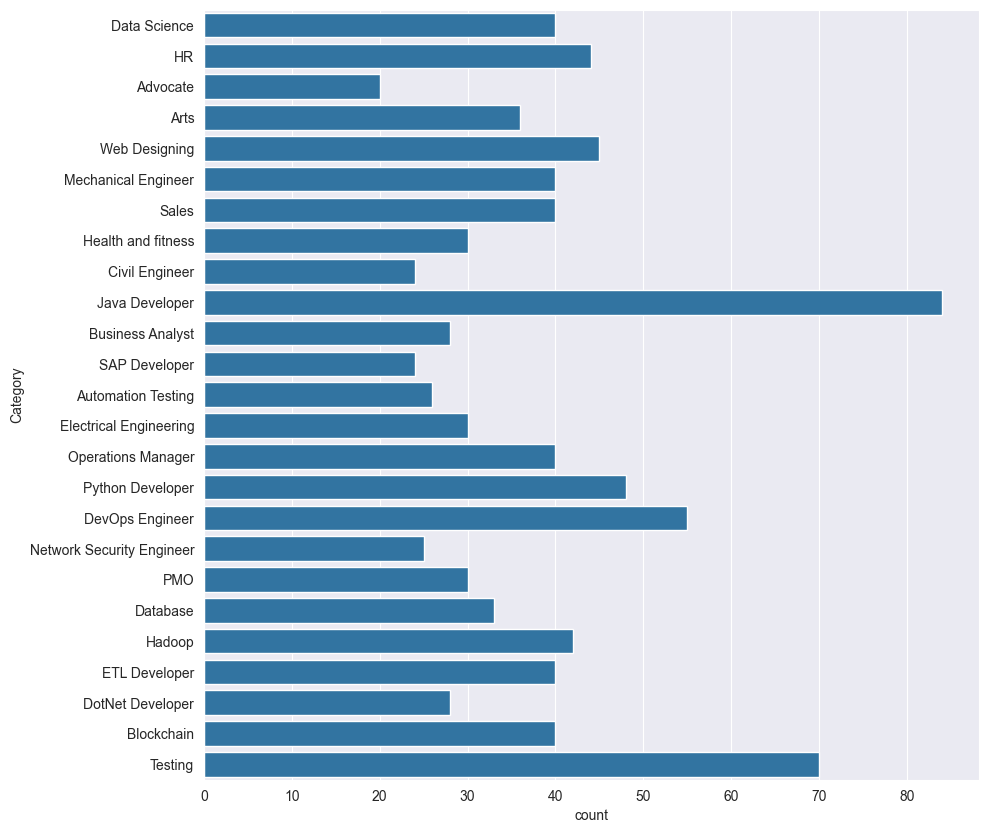

In [26]:
# Show the unique value appeared in plot for better visualization
plt.figure(figsize=(10,10))
sns.countplot(df["Category"])
plt.show()

In [27]:
# Find out the total unique values in the data
df["Category"].unique()

array(['Data Science', 'HR', 'Advocate', 'Arts', 'Web Designing',
       'Mechanical Engineer', 'Sales', 'Health and fitness',
       'Civil Engineer', 'Java Developer', 'Business Analyst',
       'SAP Developer', 'Automation Testing', 'Electrical Engineering',
       'Operations Manager', 'Python Developer', 'DevOps Engineer',
       'Network Security Engineer', 'PMO', 'Database', 'Hadoop',
       'ETL Developer', 'DotNet Developer', 'Blockchain', 'Testing'],
      dtype=object)

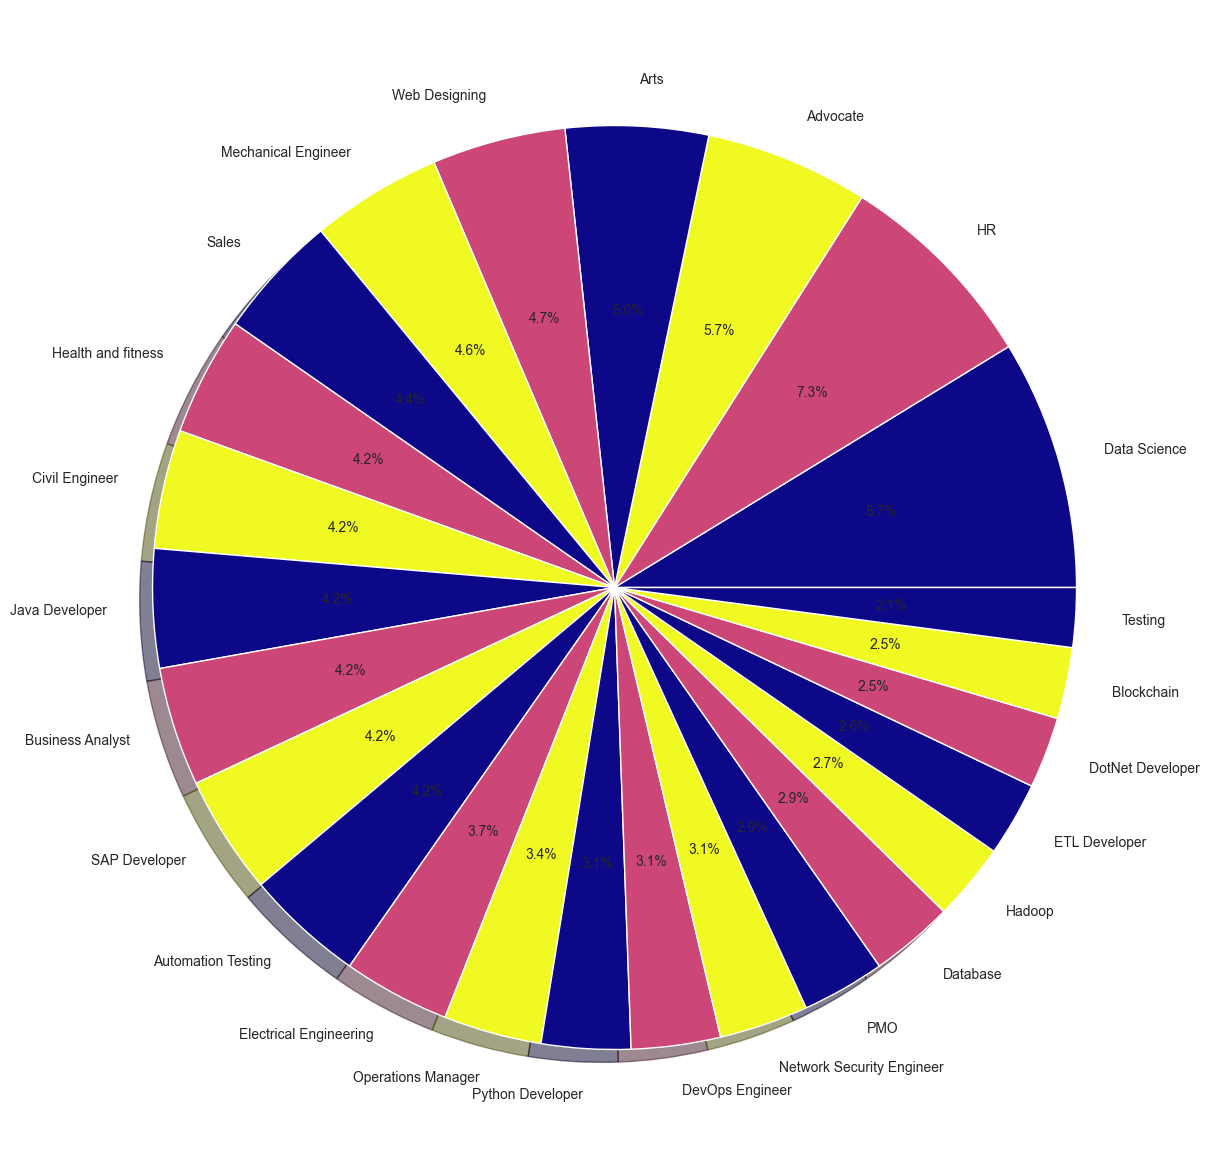

In [28]:
# Plot a pie chart to view what percentage a unique value is compared to the total
counts = df["Category"].value_counts()
labels = df["Category"].unique()


plt.figure(figsize=(20,15))
plt.pie(counts, labels=labels, autopct="%1.1f%%",shadow=True, colors=plt.cm.plasma(np.linspace(0, 1, 3)))
plt.show()

## Cleaning Data for NLP Purposes:
1. URLs
2. hashtags,
3. mentions,
4. special letters,
5. punctuations:

In [29]:
# Import the re library
# The re library is used for working with regular expressions.
# It's main function is to find, match, search for, and manipulate text based on patterns
# Step 1: Remove the URL using a pattern that finds URLs starting with http, https, or www
# Step 2: Remove email addresses
# Step 3: Remove Phone  numbers
# Step 4: Remove social media handles (mentions & hashtags)
# Step 5: Remove non-ASCII characters (emojis, special symbols)
# Step 6: Remove punctuation and special characters
# Step 7: Consolidate extra whitespace and strip leading/trailing spaces

In [30]:
import re

def clean_resume_text(text):
    """
    Cleans raw resume text by removing URLs, emails, phone numbers,
    social media artifacts, special characters, and extra whitespace.

    Args:
        text (str): The raw text from a resume.

    Returns:
        str: The cleaned text, ready for NLP analysis.
    """
    # 1. Remove URLs
    clean_text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # 2. Remove email addresses
    clean_text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', ' ', clean_text)

    # 3. Remove phone numbers (handles various formats)
    clean_text = re.sub(r'(\(?\d{3}\)?[-.\s]?)?\d{3}[-.\s]?\d{4}', ' ', clean_text)

    # 4. Remove social media handles (mentions and hashtags)
    clean_text = re.sub(r'#\w+|@\w+', ' ', clean_text)

    # 5. Remove non-ASCII characters (emojis, special symbols)
    clean_text = re.sub(r'[^\x00-\x7f]', ' ', clean_text)

    # 6. Remove punctuation and special characters
    # Note: Keeps underscores as they can be part of technical terms (e.g., variable_names)
    clean_text = re.sub(r'[^\w\s_]', ' ', clean_text)

    # 7. Consolidate extra whitespace and strip leading/trailing spaces
    clean_text = re.sub(r'\s+', ' ', clean_text).strip()

    return clean_text

# --- Example Usage ---
resume = """
John Doe | Data Analyst
Contact: (123)-456-7890 | john.doe@email.com
Portfolio: https://github.com/johndoe
Twitter: @johndoe_profile #Data
---
Experienced in Python & SQL. I love data! 😊
"""

cleaned = clean_resume_text(resume)
print(cleaned)

John Doe Data Analyst Contact Portfolio Twitter Experienced in Python SQL I love data


In [31]:
# Apply the cleaning function to every resume in the dataset
df["Cleaned_Resume"] = df["Resume"].apply(lambda x: clean_resume_text(x))

# Check the first few cleaned resumes
print(df[["Resume", "Cleaned_Resume"]].head())

                                              Resume  \
0  Skills * Programming Languages: Python (pandas...   
1  Education Details \r\nMay 2013 to May 2017 B.E...   
2  Areas of Interest Deep Learning, Control Syste...   
3  Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...   
4  Education Details \r\n MCA   YMCAUST,  Faridab...   

                                      Cleaned_Resume  
0  Skills Programming Languages Python pandas num...  
1  Education Details May 2013 to May 2017 B E UIT...  
2  Areas of Interest Deep Learning Control System...  
3  Skills R Python SAP HANA Tableau SAP HANA SQL ...  
4  Education Details MCA YMCAUST Faridabad Haryan...  


In [32]:
# Converting the cleaned text into numerical features (TF-IDF vectorization).
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=3000, stop_words="english")

X = vectorizer.fit_transform(df["Cleaned_Resume"])
y = df["Category"]


In [33]:
# Splitting the data
from sklearn.model_selection import train_test_split
X_train,  X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [34]:
# Train your model and evaluate
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
model = LinearSVC()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9948186528497409


In [35]:
# Create a function that test new resumes (text input) and see what category they belong to.
def screen_resume(resume_text):
  # Clean the input text (just like you cleaned the dataset)
  cleaned_text = clean_resume_text(resume_text)
  # Convert the cleaned text into TF-IDF features
  vectorized_text = vectorizer.transform([cleaned_text])
  #  Predict the category using the trained SVM model
  # The [0] simply picks the first (and only) element from that array.
  # Without [0], the output would look like: array(['Data Science'], dtype=object)
  # But with [0], you get a clean string: 'Data Science'
  prediction = model.predict(vectorized_text)[0]

  # Return the predicted job category
  return prediction

In [36]:
# Import the Pickle library to save your model and its tools
import pickle

# Save the trained model
with open("model.pkl", "wb") as model_file:
    pickle.dump(model, model_file)

# Save the vectorizer
with open("vectorizer.pkl", "wb") as vec_file:
    pickle.dump(vectorizer, vec_file)
